In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_public = pd.read_csv('healthy-food-survey-public.csv')
df_public

,food,yes,no,no_opinion
0,almonds,913,55,24
1,apples,945,31,7
2,avocados,882,88,59
3,baked potatoes,666,248,26
4,butter,338,600,34
5,canned tuna,704,243,62
6,carrots,935,44,16
7,cashews,826,133,35
8,cheddar cheese,531,362,60
9,chicken,883,73,14


In [7]:
df_public['public']= df_public.eval('yes/(yes+ no + no_opinion)')
df_public['public'] = df_public.eval('public*100').round()
df_public

,food,yes,no,no_opinion,public
0,almonds,913,55,24,92.0
1,apples,945,31,7,96.0
2,avocados,882,88,59,86.0
3,baked potatoes,666,248,26,71.0
4,butter,338,600,34,35.0
5,canned tuna,704,243,62,70.0
6,carrots,935,44,16,94.0
7,cashews,826,133,35,83.0
8,cheddar cheese,531,362,60,56.0
9,chicken,883,73,14,91.0


In [8]:
df_public = df_public[['food','public']]
df_public

,food,public
0,almonds,92.0
1,apples,96.0
2,avocados,86.0
3,baked potatoes,71.0
4,butter,35.0
5,canned tuna,70.0
6,carrots,94.0
7,cashews,83.0
8,cheddar cheese,56.0
9,chicken,91.0


In [9]:
df_experts = pd.read_csv('healthy-food-survey-experts.csv')

In [10]:
df_experts['expert']= df_experts.eval('yes/(yes + no + no_opinion)')
df_experts['expert']= df_experts.eval('expert * 100').round()
df_experts

,food,yes,no,no_opinion,expert
0,almonds,312,6,2,98.0
1,apples,313,1,3,99.0
2,avocados,308,9,6,95.0
3,baked potatoes,226,69,19,72.0
4,butter,131,158,42,40.0
5,canned tuna,279,37,18,84.0
6,carrots,324,2,2,99.0
7,cashews,270,21,8,90.0
8,cheddar cheese,197,116,32,57.0
9,chicken,282,11,17,91.0


In [11]:
df_experts = df_experts[['food', 'expert']]
df_experts

,food,expert
0,almonds,98.0
1,apples,99.0
2,avocados,95.0
3,baked potatoes,72.0
4,butter,40.0
5,canned tuna,84.0
6,carrots,99.0
7,cashews,90.0
8,cheddar cheese,57.0
9,chicken,91.0


In [14]:
df = df_public.merge(df_experts, on= 'food', how= 'left')
df

,food,public,expert
0,almonds,92.0,98.0
1,apples,96.0,99.0
2,avocados,86.0,95.0
3,baked potatoes,71.0,72.0
4,butter,35.0,40.0
5,canned tuna,70.0,84.0
6,carrots,94.0,99.0
7,cashews,83.0,90.0
8,cheddar cheese,56.0,57.0
9,chicken,91.0,91.0


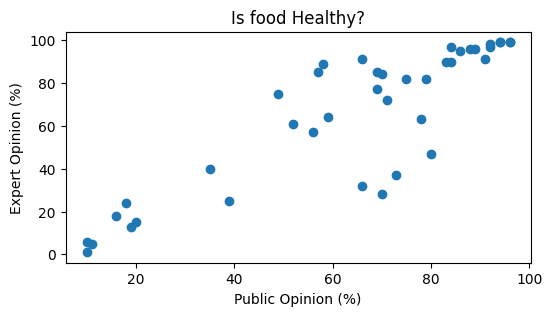

In [16]:
plt.figure(figsize=(6,3))
plt.scatter(df['public'], df['expert'])
plt.xlabel('Public Opinion (%)')
plt.ylabel('Expert Opinion (%)')
plt.title('Is food Healthy?')
plt.show()

In [17]:
def format_plot():
    plt.xlabel('Public Opinion (%)')
    plt.ylabel('Expert Opinion (%)')
    plt.title('Is food Healthy?')

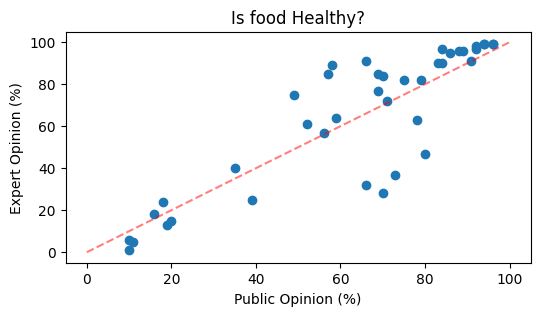

In [28]:
plt.figure(figsize=(6,3))
plt.scatter(df['public'], df['expert'])
format_plot()

x =[0, 50, 100]
y = [0, 50, 100]

plt.plot(x, y, color= 'red', alpha= 0.5, linestyle= 'dashed')

In [20]:
def add_equality():
    x =[0, 50, 100]
    y =[0, 50, 100]
    plt.plot(x,y, color= 'red', alpha= 0.5, linestyle= 'dashed')

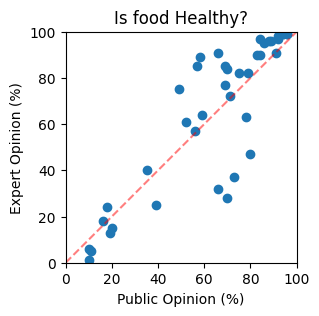

In [22]:
plt.figure(figsize=(6,3))
plt.scatter(df['public'], df['expert'])
format_plot()
add_equality()

plt.xlim(0, 100)
plt.ylim(0, 100)
ax = plt.gca()
ax.set_aspect(1)
plt.show()

In [ ]:
def square_plot():
    plt.xlim(0,100)
    plt.ylim(0,100)
    ax =plt.gca()
    ax.set_aspect(1)

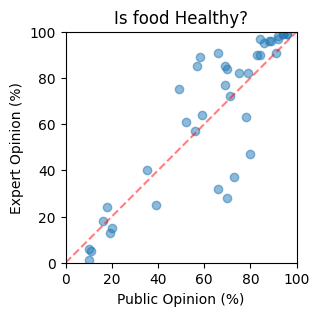

In [29]:
plt.figure(figsize=(6,3))
plt.scatter(df['public'], df['expert'], alpha= 0.5)
add_equality()
format_plot()
square_plot()
plt.show()

In [31]:
df['public_minus_expert']= df.eval('public - expert')
df = df.sort_values(by= 'public_minus_expert', ascending= False)
df.head()

,food,public,expert,public_minus_expert
19,granola bar,70.0,28.0,42.0
11,coconut oil,73.0,37.0,36.0
17,frozen yogurt,66.0,32.0,34.0
18,granola,80.0,47.0,33.0
26,orange juice,78.0,63.0,15.0
